# MODIS NIR Data Preprocessing
Description: This notebook processes the raw MODIS Near-Infrared (NIR) data of the glaciers. It calculates data quality weights based on sensor zenith angle and 'clearPixelPercentage', and applies a time-aware smoothing function.

In [1]:
# Setup and Imports
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import glob
import os

# Define Directories
MODIS_DIR = '../data/MODIS_data/raw_fulltime'
OUTPUT_DIR = '../Data/MODIS_data/weighted_data'

## 1. Data Loading and Initial Cleaning
We load the raw MODIS data for all glaciers and immediately filter for the specific years and summer months (May through October). We also ensure all numeric columns are correctly typed and drop any observations missing values. Calculate the clear pixel percentage by dividing the 'clearPixelCount' count by the 'totalPixelCount'

In [2]:
modis_files = glob.glob(f"{MODIS_DIR}/Glacier_NIR_Terra_SCAF_*.csv")
modis_glaciers = {}

for file_path in modis_files:
    file_name = os.path.basename(file_path)
    glacier_name = file_name.split('_')[-1].replace('.csv', '').capitalize()
    
    df = pd.read_csv(file_path)
    
    # Format datatypes
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['meanNIR'] = pd.to_numeric(df['meanNIR'], errors='coerce')
    df['meanSensorZenith'] = pd.to_numeric(df['meanSensorZenith'], errors='coerce')
    df['clearPixelCount'] = pd.to_numeric(df['clearPixelCount'], errors='coerce')
    df['totalPixelCount'] = pd.to_numeric(df['totalPixelCount'], errors='coerce')
    
    # Filter for specific years and summer months
    df = df[(df['date'].dt.year >= 2000) & (df['date'].dt.year <= 2025)].copy()
    df = df[df['date'].dt.month.between(5, 10)].copy()

    # Calculate clear pixel percentage
    if 'clearPixelPercentage' not in df.columns:
        df['clearPixelPercentage'] = np.where(
            df['totalPixelCount'] > 0,
            100 * df['clearPixelCount'] / df['totalPixelCount'],
            np.nan
        )
    else:
        df['clearPixelPercentage'] = pd.to_numeric(df['clearPixelPercentage'], errors='coerce')

    # Drop incomplete data, sort, and save
    df = df.dropna(subset=['date', 'meanNIR', 'meanSensorZenith', 'clearPixelPercentage']).copy()
    df = df.sort_values('date').reset_index(drop=True)
    
    modis_glaciers[glacier_name] = df

print(f"Successfully loaded and cleaned {len(modis_glaciers)} glaciers.")

Successfully loaded and cleaned 22 glaciers.


## 2. Quality Weighting and Daily Aggregation
Define two weights on every observation based on their properties. One weight is based on the sensors zenith angle, and one is based on the Clear Pixel Percentage of the image. Finally both weights get combined to one confidence weight for each observation. Each way is trusted the same, so simply multiply the weights to get the final confidence weight. 

In [3]:
#Define the weighting function for the sensor zenith
def calculate_zenith_weight(angle):
    """
    0° gets 1.0 weight.
    50° or higher gets 0.1 weight.
    Linearly decreases between 0° and 50°.
    """
    perfect_threshold = 0.0
    penalty_threshold = 50.0
    max_weight = 1.0
    min_weight = 0.1
    
    if pd.isna(angle):
        return min_weight        
    if angle <= 0.0:
        return max_weight
    elif angle >= 50.0:
        return min_weight
    else:
        fraction = (angle - perfect_threshold) / (penalty_threshold - perfect_threshold)
        return max_weight - (fraction * (max_weight - min_weight))

#Define the weighting function for the clear pixel percentage
def calculate_cloud_weight(cp):
    """
    100% clear gets 1.0 weight.
    70% clear or lower gets 0.5 weight.
    Linearly increase between 70% and 100%.
    """
    perfect_threshold = 100.0
    penalty_threshold = 70.0
    max_weight = 1.0
    min_weight = 0.5
    
    if pd.isna(cp):
        return min_weight
        
    if cp >= perfect_threshold:
        return max_weight
    elif cp <= penalty_threshold:
        return min_weight
    else:
        fraction = (cp - penalty_threshold) / (perfect_threshold - penalty_threshold)
        return min_weight + (fraction * (max_weight - min_weight))

# Apply the functions to all the glaciers
for name, df in modis_glaciers.items():
    
    df['weight_sensorZenith'] = df['meanSensorZenith'].apply(calculate_zenith_weight)
    df['weight_clearPixel'] = df['clearPixelPercentage'].apply(calculate_cloud_weight)
    
    # Combine weights to one single weight
    df['MODIS_weight_final'] = (df['weight_sensorZenith'] * df['weight_clearPixel']).round(4)
    
    # Save back into the dictionary
    modis_glaciers[name] = df

## 3. Aggregate multiple data on the same day
If there were taken several images on one day, one average weighted value gets calculated here. 

In [4]:
# Define the weighted mean function
def weighted_mean(values, weights):
    """Calculates a weighted mean while ignoring bad data/NaNs."""
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mask = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

# Squash multiple daily passes for all glaciers
for name, df in modis_glaciers.items():
    
    # Combine multiple satellite data into one value per day
    daily = (
        df.groupby('date')
          .apply(lambda g: pd.Series({
              'meanNIR': weighted_mean(g['meanNIR'], g['MODIS_weight_final']),
              'meanSensorZenith': weighted_mean(g['meanSensorZenith'], g['MODIS_weight_final']),
              'clearPixelPercentage': weighted_mean(g['clearPixelPercentage'], g['MODIS_weight_final']),
              # For the daily weight --> just take the standard average
              'MODIS_weight_final': g['MODIS_weight_final'].mean() 
          }))
          .reset_index()
          .sort_values('date')
    )
    
    # Round data
    cols_to_round = ['meanNIR', 'meanSensorZenith', 'clearPixelPercentage', 'MODIS_weight_final']
    daily[cols_to_round] = daily[cols_to_round].round(4)

    modis_glaciers[name] = daily

## 4. Time-Aware Smoothing
To represent the seasonal evolution of the glacier surface, we apply a time-aware moving average to the NIR data. Three different window sizes get tested to find the optimal smoothing. A window size of 7 days, 14 days and 21 days gets applied. 

In [5]:
# Define a mulit-window MODIS NIR smoothing function
def smooth_modis_multi_window(df, windows=[7, 14, 21]):
    """
    A time-based smoothing function for MODIS NIR.
    Loops through the list of window sizes (7, 14, 21 days).
    Calculates both weighted and unweighted smoothing for every window.
    """
    date_col='date'
    weight_col='MODIS_weight_final'
    
    # 1. Sort by date
    df_sorted = df.sort_values(date_col).copy()
    df_sorted[date_col] = pd.to_datetime(df_sorted[date_col])
    
    # 2. Build daily calendar
    full_dates = pd.date_range(df_sorted[date_col].min(), df_sorted[date_col].max(), freq='D')
    calendar = pd.DataFrame(index=full_dates)
    calendar.index.name = date_col
    
    # 3. Put the actual observed data onto the calendar
    obs = df_sorted[[date_col, 'meanNIR', weight_col]].copy()
    obs = obs.set_index(date_col)
    merged = calendar.join(obs, how='left')

    # 4. Loop through every window size
    for w in windows:
        # calculate unweighted smoothing
        merged[f'meanNIR_unweighted_{w}day'] = merged['meanNIR'].rolling(
            window=w, center=True, min_periods=1
        ).mean().round(4)

        # calculate weighted smoothing
        merged['temp_vw'] = merged['meanNIR'] * merged[weight_col]
        rolling_num = merged['temp_vw'].rolling(window=w, center=True, min_periods=1).sum()
        rolling_den = merged[weight_col].rolling(window=w, center=True, min_periods=1).sum()
        
        merged[f'meanNIR_weighted_{w}day'] = (rolling_num / rolling_den).round(4)
        
        # Drop the temporary column before the next loop iteration
        merged = merged.drop(columns=['temp_vw'])

    # 5. Clean up
    final_df = merged.dropna(subset=['meanNIR']).reset_index()
    
    # Convert dates back to string format
    final_df[date_col] = final_df[date_col].dt.strftime('%Y-%m-%d')
    
    return final_df

# Apply the smoothing function to every glacier
for name, df in modis_glaciers.items():
    
    nir_smooth = smooth_modis_multi_window(df, windows=[7, 14, 21])
    
    modis_glaciers[name] = nir_smooth

## 5. Visualization of the three different smoothing methods
To see the effect of the smoothing in the three different window sizes plot them all together. 

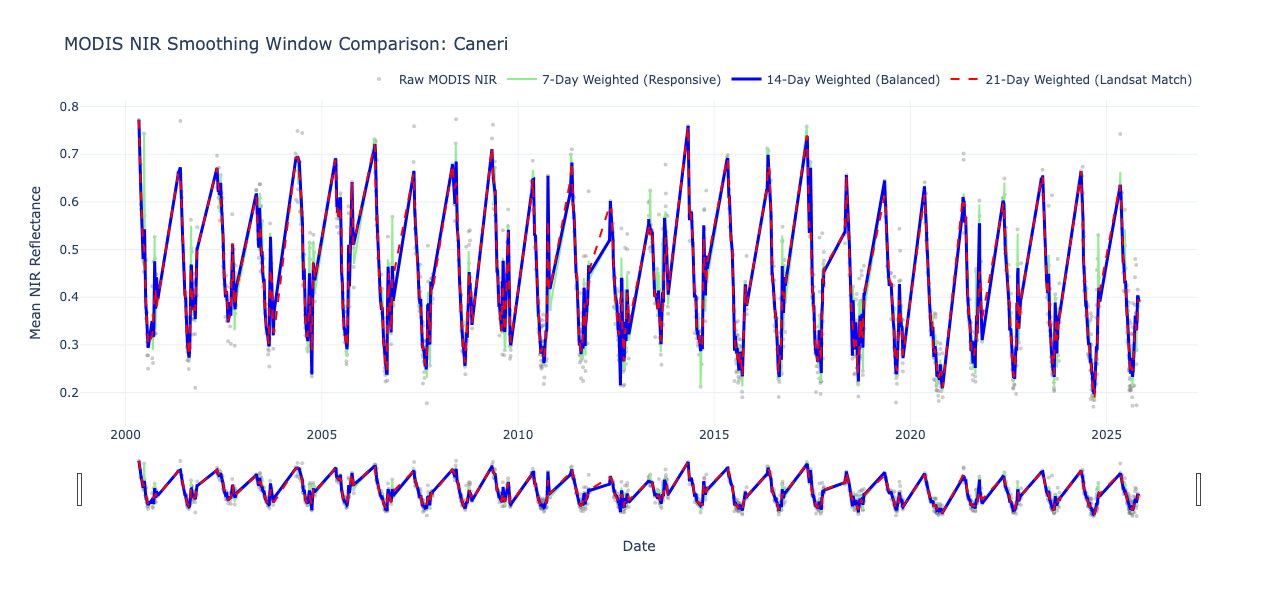

In [6]:
# Visualise the three different smoothing windows together
GLACIER_TO_PLOT = 'Caneri'

if GLACIER_TO_PLOT in modis_glaciers:
    df_plot = modis_glaciers[GLACIER_TO_PLOT]

    fig_modis_overlay = go.Figure()

    # Raw MODIS Data 
    fig_modis_overlay.add_trace(go.Scatter(
        x=df_plot['date'], y=df_plot['meanNIR'],
        mode='markers', name='Raw MODIS NIR', 
        marker=dict(color='gray', opacity=0.4, size=4)
    ))

    # 10-Day Window 
    fig_modis_overlay.add_trace(go.Scatter(
        x=df_plot['date'], y=df_plot['meanNIR_weighted_7day'],
        mode='lines', name='7-Day Weighted (Responsive)', 
        line=dict(color='lightgreen', width=2)
    ))

    # 15-Day Window 
    fig_modis_overlay.add_trace(go.Scatter(
        x=df_plot['date'], y=df_plot['meanNIR_weighted_14day'],
        mode='lines', name='14-Day Weighted (Balanced)', 
        line=dict(color='blue', width=3)
    ))

    # 20-Day Window 
    fig_modis_overlay.add_trace(go.Scatter(
        x=df_plot['date'], y=df_plot['meanNIR_weighted_21day'],
        mode='lines', name='21-Day Weighted (Landsat Match)', 
        line=dict(color='red', width=2, dash='dash')
    ))

    # Layout and Formatting
    fig_modis_overlay.update_layout(
        title=f"MODIS NIR Smoothing Window Comparison: {GLACIER_TO_PLOT}",
        height=600, 
        template="plotly_white", 
        hovermode='x unified',
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig_modis_overlay.update_yaxes(title_text="Mean NIR Reflectance")
    fig_modis_overlay.update_xaxes(title_text="Date")

    fig_modis_overlay.update_xaxes(rangeslider_visible=True)

    fig_modis_overlay.show()
else:
    print(f"Error: Could not find '{GLACIER_TO_PLOT}' in your data dictionary.")

## 6. 7-day Smoothing Visualization
Comparison of the raw observations versus the unweighted and weighted smoothing methodologies only for the 7 day smoothing window.

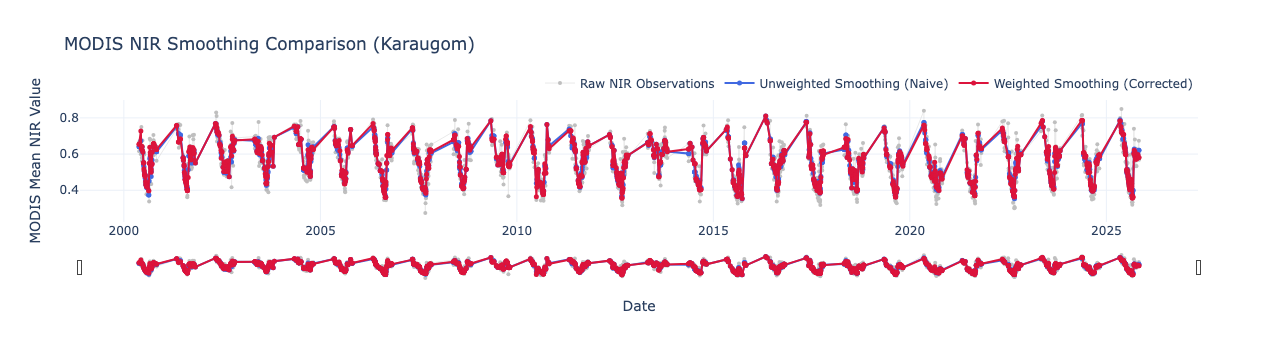

In [7]:
# Visualize the weighted vs. unweighted 7-day smoothing result
GLACIER_TO_PLOT = 'Karaugom' 
df = modis_glaciers[GLACIER_TO_PLOT]

fig_smooth = go.Figure()

# Raw MODIS NIR Data 
fig_smooth.add_trace(go.Scatter(
    x=df['date'], 
    y=df['meanNIR'],
    mode='lines+markers',
    name='Raw NIR Observations',
    line=dict(color='lightgrey', width=1),
    marker=dict(color='grey', size=4),
    opacity=0.5 
))

# Unweighted Smoothing 
fig_smooth.add_trace(go.Scatter(
    x=df['date'], 
    y=df['meanNIR_unweighted_14day'], 
    mode='lines+markers',
    name='Unweighted Smoothing (Naive)',
    line=dict(color='royalblue', width=2),
    marker=dict(color='royalblue', size=5)
))

# Weighted Smoothing 
fig_smooth.add_trace(go.Scatter(
    x=df['date'], 
    y=df['meanNIR_weighted_14day'],
    mode='lines+markers',
    name='Weighted Smoothing (Corrected)',
    line=dict(color='crimson', width=2),
    marker=dict(color='crimson', size=5)
))

# Layout
fig_smooth.update_layout(
    title=f"MODIS NIR Smoothing Comparison ({GLACIER_TO_PLOT})",
    xaxis_title="Date",
    yaxis_title="MODIS Mean NIR Value",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig_smooth.update_xaxes(rangeslider_visible=True)
fig_smooth.show()

## 6. Final Export
Export the newly created data. Only the weightd and unweighted smoothing with the window size of 7 days gets exported, as this will be the data to continue working with. 

In [8]:
os.makedirs(OUTPUT_DIR, exist_ok=True) 

modis_columns_to_keep = [
    'date',
    'meanNIR',
    'MODIS_weight_final',
    'meanNIR_unweighted_7day', 
    'meanNIR_weighted_7day',
]

for name, df in modis_glaciers.items():
    df_complete = df[modis_columns_to_keep].copy()
    output_path = f"{OUTPUT_DIR}/MODIS_{name}_complete.csv"
    df_complete.to_csv(output_path, index=False)

print(f"Data successfully exported to: {OUTPUT_DIR}")

Data successfully exported to: ../Data/MODIS_data/weighted_data
